In [1]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import json


In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
import os
print(os.getcwd())
# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)
if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

/home/vazeta/Desktop/GenerativeAI/TP1-alunos-src-only/student_start_pack
PROJECT_ROOT = ..
KAGGLE_ROOT  = ../ArtBench-10
PROJECT_ROOT = ..
KAGGLE_ROOT  = ../ArtBench-10


In [3]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

/home/vazeta/Desktop/GenerativeAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset source: kaggle root='../ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [4]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


In [5]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2
USE_SAVED_MODELS_IF_AVAILABLE = False

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [6]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

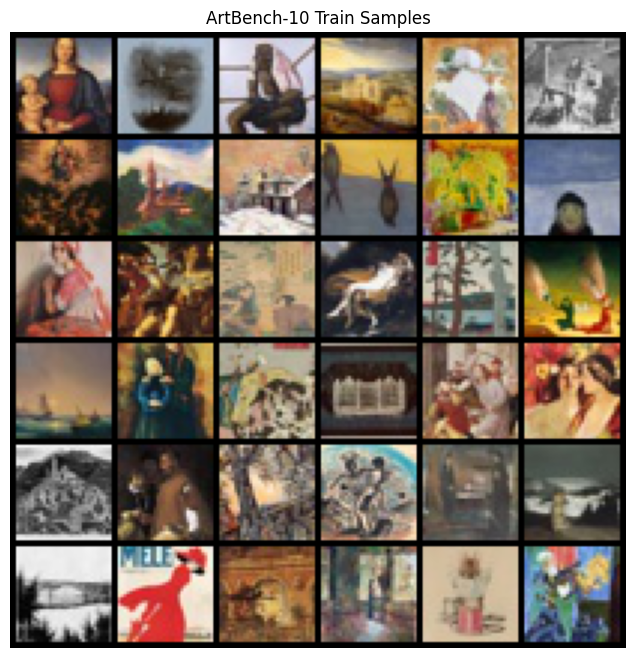

Labels: ['renaissance', 'romanticism', 'expressionism', 'romanticism', 'post_impressionism', 'realism', 'renaissance', 'post_impressionism', 'post_impressionism', 'surrealism', 'post_impressionism', 'expressionism', 'art_nouveau', 'baroque', 'ukiyo_e', 'romanticism', 'ukiyo_e', 'surrealism', 'romanticism', 'post_impressionism', 'ukiyo_e', 'surrealism', 'renaissance', 'art_nouveau', 'realism', 'baroque', 'expressionism', 'surrealism', 'expressionism', 'realism', 'realism', 'art_nouveau', 'impressionism', 'expressionism', 'art_nouveau', 'post_impressionism']


In [7]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader_from_csv, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

In [8]:
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print(device)

cuda


In [9]:
MODEL_DIR = Path('./models')
HISTORY_DIR = Path('./histories')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)


def _artifact_stem(run_name):
    stem = ''.join(ch.lower() if ch.isalnum() else '_' for ch in run_name)
    stem = '_'.join(part for part in stem.split('_') if part)
    return stem or 'model'


def _artifact_paths(run_name):
    stem = _artifact_stem(run_name)
    return MODEL_DIR / f'{stem}.pt', HISTORY_DIR / f'{stem}.json'


def fit_or_load_model(model, run_name, train_fn, load_if_available=USE_SAVED_MODELS_IF_AVAILABLE, **train_kwargs):
    model_path, history_path = _artifact_paths(run_name)

    if load_if_available and model_path.exists():
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        if history_path.exists():
            with history_path.open('r', encoding='utf-8') as f:
                history = json.load(f)
        else:
            history = []
        print(f'Loaded {run_name} model from {model_path}')
        return history

    history = train_fn(model=model, **train_kwargs)
    with model_path.open('wb') as f:
        torch.save(model.state_dict(), f)
    with history_path.open('w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)
    print(f'Saved {run_name} model to {model_path} and history to {history_path}')
    return history


In [10]:
LATENT_DIM  = 128
EPOCHS      = 100
LR          = 1e-3
BETA        = 0.5
USE_SAVED_MODELS_IF_AVAILABLE = False

SAMPLES_DIR = Path('./vae_samples')
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

SPATIAL_FLAT = 256 * 4 * 4  # 4096

# Varionational Auto-Encoder

In [11]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
 
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
 
        self.fc_mu = nn.Linear(SPATIAL_FLAT, latent_dim)
        self.fc_logvar = nn.Linear(SPATIAL_FLAT, latent_dim)
 
        self.dec_fc = nn.Linear(latent_dim, SPATIAL_FLAT)
 
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Sigmoid(),
        )
 
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
                nn.init.normal_(m.weight, 0.0, 0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
 
    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
 
    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu
 
    def decode(self, z):
        h = self.dec_fc(z)
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder(h)
 
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar
 
    @torch.no_grad()
    def sample(self, n: int, device: torch.device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decode(z)

In [12]:
def vae_loss(xhat, x, mu, logvar, beta: float = 1.0,):
    B = x.size(0)
    recon = F.mse_loss(xhat, x, reduction="sum") / B
    kl = -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp()) / B
    total = recon + beta * kl
    return total, recon, kl


def train_vae(model, loader, optimizer, epochs=EPOCHS, beta_max=BETA, scheduler=None):
    from tqdm import tqdm
    model.train()
    history = []

    for ep in range(1, epochs + 1):
        beta = min(beta_max, beta_max * (ep / (epochs * 0.6)))
        total_loss = recon_loss = kl_loss = 0.0

        for x, _y, _idx in tqdm(loader, desc=f"Epoch {ep}/{epochs}", leave=False):
            x = x.to(device)
            optimizer.zero_grad()
            xhat, mu, logvar = model(x)
            loss, recon, kl  = vae_loss(xhat, x, mu, logvar, beta=beta)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            n = x.size(0)
            total_loss += loss.item()  * n
            recon_loss += recon.item() * n
            kl_loss += kl.item()   * n

        if scheduler is not None:
            scheduler.step()

        N = len(loader.dataset)
        entry = {
            "epoch": ep,
            "train_loss": total_loss / N,
            "train_recon": recon_loss / N,
            "train_kl": kl_loss   / N,
        }
        history.append(entry)
        print(
            f"Epoch {ep:3d}/{epochs} | "
            f"loss={entry['train_loss']:.4f}  "
            f"recon={entry['train_recon']:.4f}  "
            f"kl={entry['train_kl']:.4f}"
        )

        if ep % 10 == 0 or ep == epochs:
            model.eval()
            with torch.no_grad():
                z = torch.randn(64, model.latent_dim, device=device)
                samples = model.decode(z)
            save_image(samples, SAMPLES_DIR / f"samples_ep{ep:04d}.png", nrow=8)
            model.train()

    return history


def evaluate_vae(model, loader, beta=BETA):
    model.eval()
    total_loss = recon_loss = kl_loss = mse_sum = mae_sum = 0.0
    n_samples = 0
    last_x = None

    with torch.no_grad():
        for x, _y, _idx in loader:
            x = x.to(device)
            xhat, mu, logvar = model(x)
            B = x.size(0)

            loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)

            total_loss += loss.item()  * B
            recon_loss += recon.item() * B
            kl_loss    += kl.item()   * B
            mse_sum    += F.mse_loss(xhat, x, reduction="sum").item()
            mae_sum    += (xhat - x).abs().sum().item()
            n_samples  += B
            last_x = x

    numel = last_x[0].numel()
    return {
        "loss": total_loss / n_samples,
        "recon_mse": recon_loss / n_samples,
        "kl": kl_loss   / n_samples,
        "mse": mse_sum   / (n_samples * numel),
        "mae": mae_sum   / (n_samples * numel),
    }

In [13]:
vae = ConvVAE(latent_dim=LATENT_DIM).to(device)
RUN_NAME = "artbench_VAE"
print(f"Total parameters: {sum(p.numel() for p in vae.parameters()):,}")

optimizer = torch.optim.Adam(vae.parameters(), lr=LR, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = fit_or_load_model(
    model=vae,
    run_name=RUN_NAME,
    train_fn=train_vae,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader_from_csv,
    optimizer=optimizer,
    epochs=EPOCHS,
    beta_max=BETA,
    scheduler=scheduler,
)

metrics = evaluate_vae(vae, train_loader_from_csv, beta=BETA)
print("Metrics:")
for k, v in metrics.items():
    print(f" {k}: {v:.6f}")

Total parameters: 2,895,360


Epoch   1/100 | loss=64.4852  recon=61.6977  kl=334.4941


Epoch   2/100 | loss=42.9724  recon=38.7417  kl=253.8417


Epoch   3/100 | loss=38.7941  recon=33.6035  kl=207.6213


Epoch   4/100 | loss=37.1133  recon=31.0486  kl=181.9426


...

Epoch  96/100 | loss=53.7120  recon=36.2864  kl=34.8512


Epoch  97/100 | loss=53.7479  recon=36.3124  kl=34.8711


Epoch  98/100 | loss=53.7210  recon=36.3148  kl=34.8125


Epoch  99/100 | loss=53.6572  recon=36.2749  kl=34.7646


Epoch 100/100 | loss=53.7074  recon=36.2888  kl=34.8372
Saved artbench_VAE model to models/artbench_vae.pt and history to histories/artbench_vae.json
Metrics:
 loss: 46.799989
 recon_mse: 29.223207
 kl: 35.153564
 mse: 0.009513
 mae: 0.072959


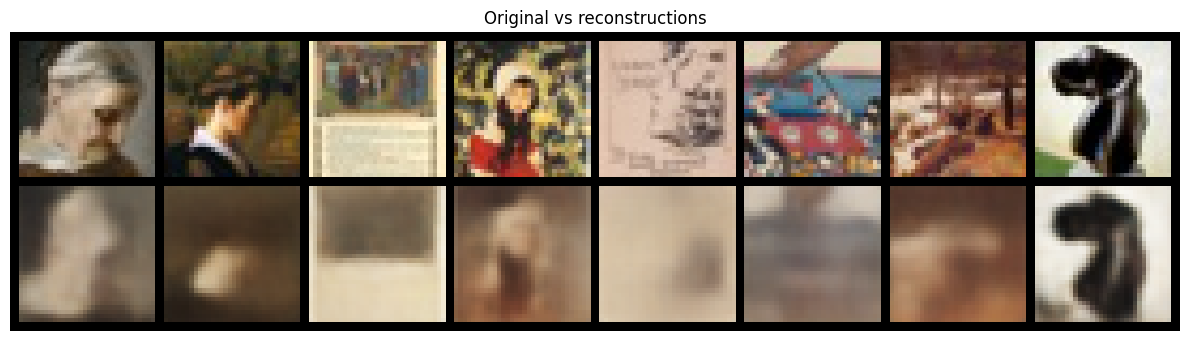

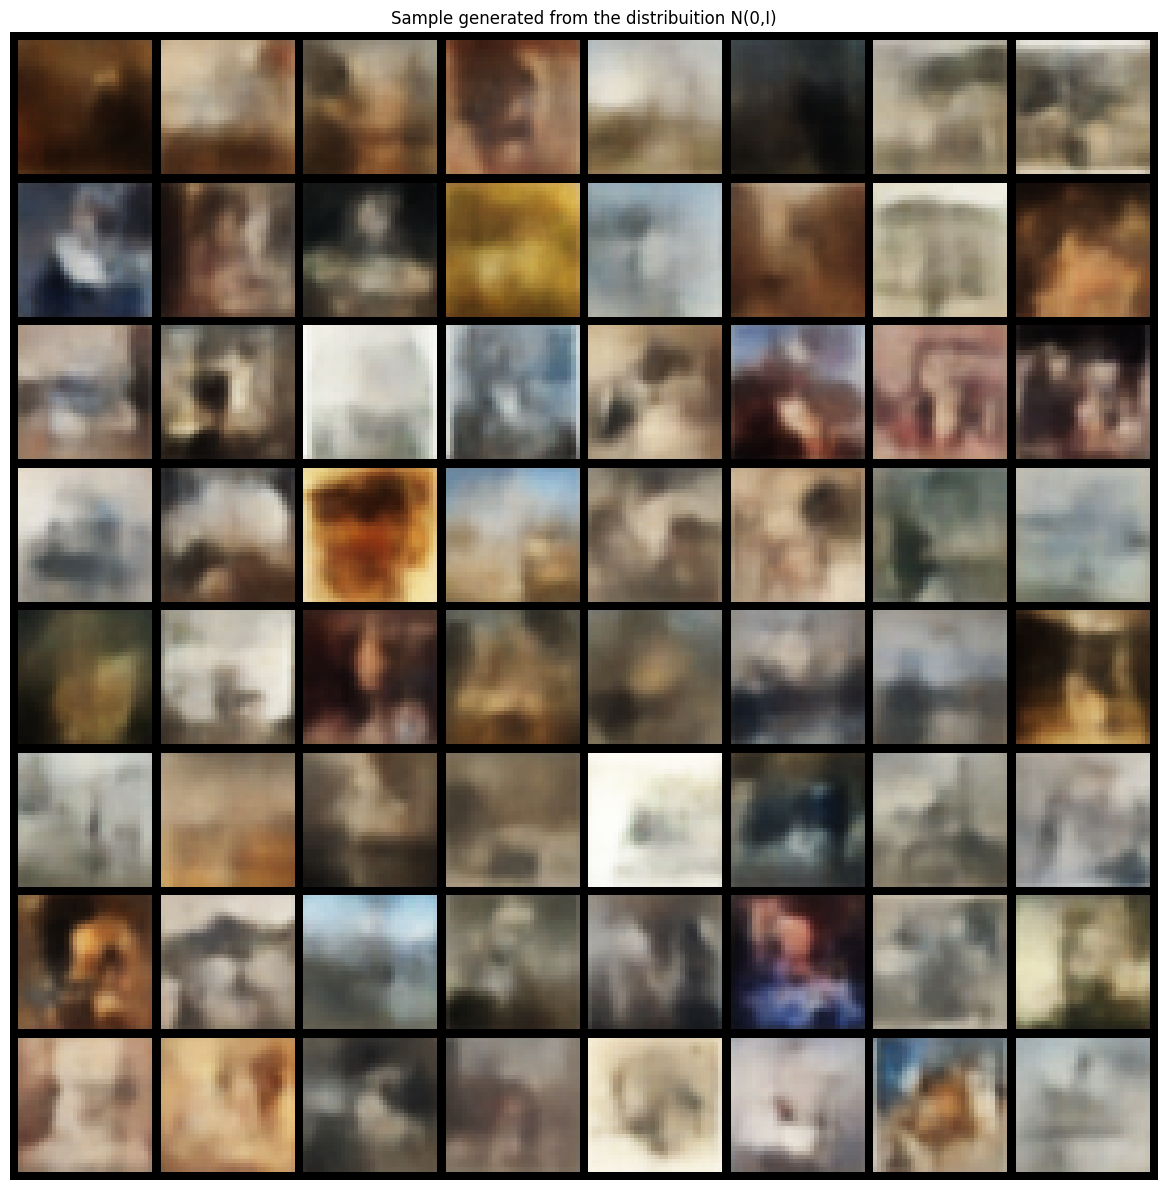

In [14]:
def show_reconstructions(model, loader, n=8):
    model.eval()
    x, _y, _idx = next(iter(loader))
    x = x[:n].to(device)

    with torch.no_grad():
        xhat, _, _ = model(x)

    comparison = torch.cat([x.cpu(), xhat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(n * 1.5, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("Original vs reconstructions")
    plt.tight_layout()
    plt.show()


def show_prior_samples(model, n=64, nrow=8):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim, device=device)
        samples = model.decode(z)

    grid = make_grid(samples.cpu(), nrow=nrow, padding=2)

    plt.figure(figsize=(nrow * 1.5, (n // nrow) * 1.5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("Sample generated from the distribuition N(0,I)")
    plt.tight_layout()
    plt.show()


show_reconstructions(vae, train_loader_from_csv, n=8)
show_prior_samples(vae, n=64, nrow=8)